In [1]:
# Cell 1 — Install dependencies

!pip install pyarrow pandas scikit-learn xgboost mlflow requests matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.6/887.6 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

In [2]:
# Cell 2 — Databricks credentials

import os
from google.colab import userdata

# DATABRICKS_TOKEN (Colab Secret) should points to your Databricks workspace URL

DATABRICKS_HOST = "https://dbc-4b695b7d-0d1d.cloud.databricks.com"
DATABRICKS_TOKEN = userdata.get("DATABRICKS_TOKEN")

assert DATABRICKS_TOKEN, "DATABRICKS_TOKEN secret not set in Colab Secrets panel"

import requests
headers = {"Authorization": f"Bearer {DATABRICKS_TOKEN}"}

r = requests.get(f"{DATABRICKS_HOST}/api/2.0/clusters/list", headers=headers)
assert r.status_code == 200, f"Connection failed: {r.status_code} {r.text}"
print("Connection successful")

Connection successful


In [3]:
# Cell 3 — Load parquet file

import pandas as pd
import os
import shutil

local_dir = "/content/silver_churn_features"
os.makedirs(local_dir, exist_ok=True)

for f in os.listdir("/content"):
    if f.endswith(".parquet"):
        shutil.move(f"/content/{f}", f"{local_dir}/{f}")
        print(f"Moved: {f}")

df = pd.read_parquet(local_dir)
print(f"Total rows:    {len(df)}")
print(f"Columns:       {df.columns.tolist()}")
print(f"\nChurn distribution:\n{df['churn'].value_counts()}")

Moved: part-00000-tid-5288049880031833700-ebab5041-a7f1-437c-b82f-cab6b4df658e-218-1.c000.snappy.parquet
Total rows:    10000
Columns:       ['customer_id', 'credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'is_germany', 'is_spain', 'is_male', 'is_zero_balance', 'balance_per_product', 'is_inactive_with_balance', 'tenure_ratio', 'is_young', 'is_senior', 'churn']

Churn distribution:
churn
0    7963
1    2037
Name: count, dtype: int64


In [4]:
# Cell 4 — Prepare features and labels

# customer_id is an identifier not a feature
feature_cols = [c for c in df.columns if c not in ["customer_id", "churn"]]

X = df[feature_cols]
y = df["churn"]

print(f"Features: {feature_cols}")
print(f"X shape:  {X.shape}")
print(f"y shape:  {y.shape}")

Features: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'is_germany', 'is_spain', 'is_male', 'is_zero_balance', 'balance_per_product', 'is_inactive_with_balance', 'tenure_ratio', 'is_young', 'is_senior']
X shape:  (10000, 17)
y shape:  (10000,)


In [5]:
# Cell 5 — Train/validation split

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # preserve 80/20 churn ratio in both splits
)

print(f"Training rows:   {len(X_train)}")
print(f"Validation rows: {len(X_val)}")
print(f"\nTrain churn rate: {y_train.mean():.2%}")
print(f"Val churn rate:   {y_val.mean():.2%}")

Training rows:   8000
Validation rows: 2000

Train churn rate: 20.38%
Val churn rate:   20.35%


In [6]:
# Cell 6 — Configure MLflow

import mlflow

os.environ["MLFLOW_TRACKING_URI"] = "databricks"
os.environ["DATABRICKS_HOST"] = DATABRICKS_HOST
os.environ["DATABRICKS_TOKEN"] = DATABRICKS_TOKEN

mlflow.set_experiment("/Users/juanjose.almonte@gmail.com/churn-classifier")
print("MLflow pointing to Databricks workspace")

2026/05/16 02:17:04 INFO mlflow.tracking.fluent: Experiment with name '/Users/juanjose.almonte@gmail.com/churn-classifier' does not exist. Creating a new experiment.


MLflow pointing to Databricks workspace


scale_pos_weight: 3


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:10:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy:  83.20%
F1 Score:  0.6364
ROC AUC:   0.8694


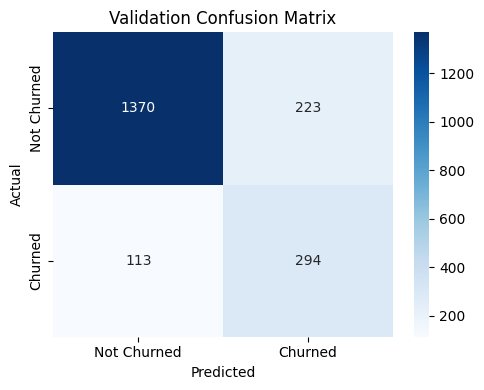


Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.92      0.86      0.89      1593
     Churned       0.57      0.72      0.64       407

    accuracy                           0.83      2000
   macro avg       0.75      0.79      0.76      2000
weighted avg       0.85      0.83      0.84      2000



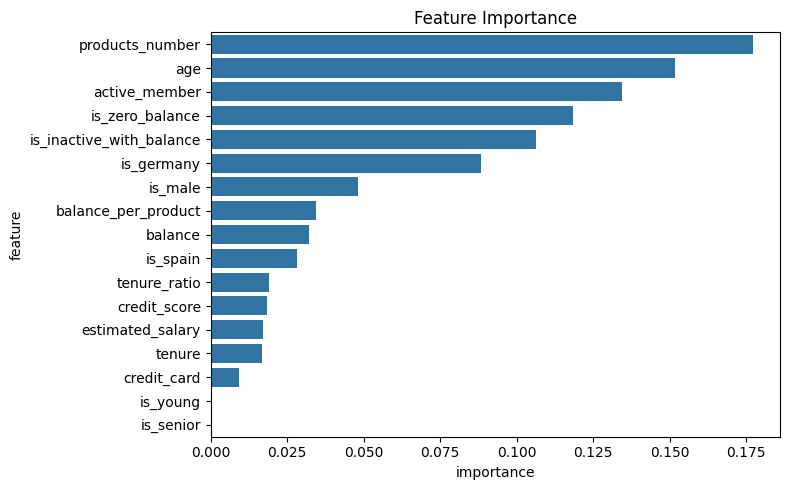


Top 5 features:
                     feature  importance
4            products_number    0.177247
1                        age    0.151699
6              active_member    0.134596
11           is_zero_balance    0.118321
13  is_inactive_with_balance    0.106455
🏃 View run xgboost-churn at: https://dbc-4b695b7d-0d1d.cloud.databricks.com/ml/experiments/2325034073639695/runs/fedc964665ab49c8924832720d9f3976
🧪 View experiment at: https://dbc-4b695b7d-0d1d.cloud.databricks.com/ml/experiments/2325034073639695


In [19]:
# Cell 7 — Train XGBoost with MLflow tracking

import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ratio of negatives to positives — handles class imbalance
scale_pos_weight = int(y_train.value_counts()[0] / y_train.value_counts()[1])
print(f"scale_pos_weight: {scale_pos_weight}")

with mlflow.start_run(run_name="xgboost-churn"):

    mlflow.log_params({
        "model": "XGBoost",
        "n_estimators": 200,
        "max_depth": 4,
        "learning_rate": 0.05,
        "scale_pos_weight": scale_pos_weight,
        "test_size": 0.2,
        "random_state": 42
    })

    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss",
        use_label_encoder=False
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    # ── Predictions ──
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    accuracy = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_prob)

    mlflow.log_metrics({
        "accuracy": round(accuracy, 4),
        "f1_score": round(f1, 4),
        "roc_auc": round(auc, 4)
    })

    print(f"Accuracy:  {accuracy:.2%}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC AUC:   {auc:.4f}")

    # ── Confusion matrix ──
    cm = confusion_matrix(y_val, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Not Churned", "Churned"],
        yticklabels=["Not Churned", "Churned"],
        ax=ax
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("Validation Confusion Matrix")
    plt.tight_layout()
    cm_path = "/content/confusion_matrix.png"
    fig.savefig(cm_path)
    mlflow.log_artifact(cm_path)
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_val, y_pred,
          target_names=["Not Churned", "Churned"]))

    # ── Feature importance ──
    importance = pd.DataFrame({
        "feature": feature_cols,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    fig2, ax2 = plt.subplots(figsize=(8, 5))
    sns.barplot(data=importance, x="importance", y="feature", ax=ax2)
    ax2.set_title("Feature Importance")
    plt.tight_layout()
    fi_path = "/content/feature_importance.png"
    fig2.savefig(fi_path)
    mlflow.log_artifact(fi_path)
    plt.show()

    print("\nTop 5 features:")
    print(importance.head())

In [20]:
# Cell 8 — Save model and label mapping

import pickle
import json

# Save model
model_path = "/content/churn_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model, f)

# Save feature column order — critical for inference
mapping = {
    "feature_cols": feature_cols,
    "label": {"0": "not_churned", "1": "churned"}
}
mapping_path = "/content/label_mapping.json"
with open(mapping_path, "w") as f:
    json.dump(mapping, f)

print("Model and mapping saved")

Model and mapping saved


In [21]:
# Cell 9 — Upload to Databricks Volume

def upload_to_volume(local_path, volume_path):
    upload_url = f"{DATABRICKS_HOST}/api/2.0/fs/files/{volume_path}"
    with open(local_path, "rb") as f:
        r = requests.put(upload_url, headers=headers, data=f)
    assert r.status_code in (200, 204), \
        f"Upload failed for {volume_path}: {r.status_code} {r.text}"
    print(f"Uploaded: {volume_path}")

upload_to_volume(
    "/content/churn_model.pkl",
    "Volumes/main/default/churn_vol/models/churn_model.pkl"
)

upload_to_volume(
    "/content/label_mapping.json",
    "Volumes/main/default/churn_vol/models/label_mapping.json"
)

upload_to_volume(
    "/content/confusion_matrix.png",
    "Volumes/main/default/churn_vol/models/confusion_matrix.png"
)

upload_to_volume(
    "/content/feature_importance.png",
    "Volumes/main/default/churn_vol/models/feature_importance.png"
)

print("\nAll artifacts uploaded to Databricks Volume")

Uploaded: Volumes/main/default/churn_vol/models/churn_model.pkl
Uploaded: Volumes/main/default/churn_vol/models/label_mapping.json
Uploaded: Volumes/main/default/churn_vol/models/confusion_matrix.png
Uploaded: Volumes/main/default/churn_vol/models/feature_importance.png

All artifacts uploaded to Databricks Volume
